In [1]:
import numpy as np 
from sklearn.datasets import fetch_20newsgroups
import json
import matplotlib.pyplot as plt
from collections import Counter

In [52]:
from cartm.preprocessing import (
    CorpusLoader,
    BatchedCorpusLoader,
    build_bow,
)

In [401]:
full_20ng = fetch_20newsgroups(data_home='./data/', subset='all', remove=('headers', 'footers', 'quotes'))
data = full_20ng.data
targets = full_20ng.target
target_names = full_20ng.target_names
#preprocessor = CorpusLoader(min_token_len=3, max_token_len=20, min_df=5, max_df=0.5)
#tokenized_data, document_bounds = preprocessor.fit_transform(data)
lower_data = {i: d.lower() for i, d in enumerate(data)}
data_targets = {i: target_names[t] for i, t in enumerate(targets)}

In [415]:
target_names[15]

'soc.religion.christian'

In [402]:
corpus_data_prefix = 'new_3_20_10_05_'
structure_prefix = 'new_eq_500_50_'
#structure_prefix = '500_50_5_src_'

In [403]:
with open(corpus_data_prefix + 'vocab.json', 'r') as file:
    vocab = json.load(file)
    reverse_vocab = {value: key for key, value in vocab.items()}

print(f"{len(vocab)=}")

len(vocab)=13029


In [404]:
phi = np.load(structure_prefix + 'phi.npy').T
print(f"{phi.shape=}")

phi.shape=(30, 13029)


anchor_result.shape=(30, 1415)


Text(0.5, 1.0, 'Распределение якорных слов по темам')

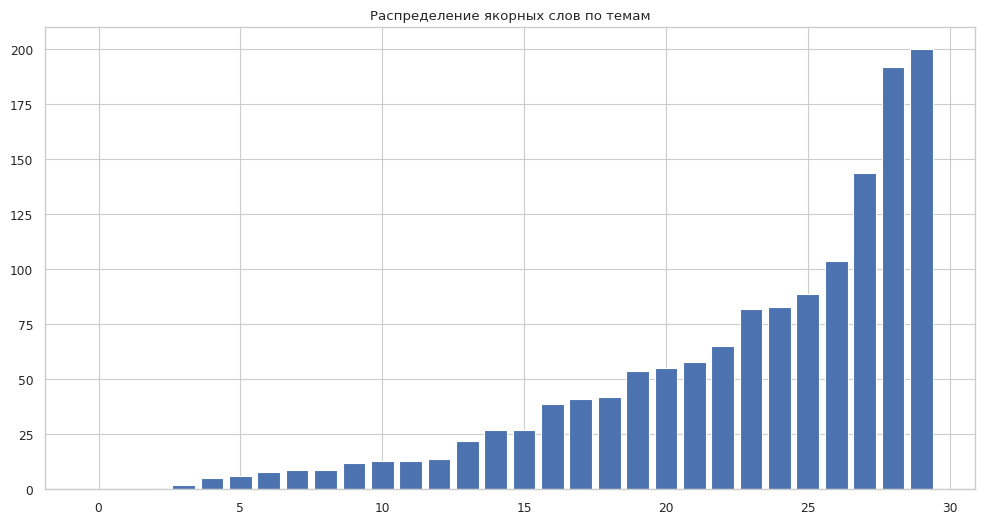

In [405]:
eps = 0
anchor_mask = (phi[:, :] >= 1 - eps).any(axis=0)  # True для столбцов (токенов), содержащих хотя бы одну 1
anchor_result = phi[:, anchor_mask]         # выборка токенов
print(f"{anchor_result.shape=}")

plt.bar(range(phi.shape[0]), np.sort(np.sum(anchor_result, axis=1)))
plt.title("Распределение якорных слов по темам")

In [406]:
topic_anchors_mask = np.where(phi[:, :] >= 1 - eps)
print(f"{topic_anchors_mask=}")
topic_anchors = [[reverse_vocab[w] for w in topic_anchors_mask[1][topic_anchors_mask[0] == t].tolist()] 
    for t in range(phi.shape[0])]
sorted_topic_anchors = sorted(topic_anchors, key=len)

topic_anchors_mask=(array([ 0,  0,  0, ..., 29, 29, 29], shape=(1415,)), array([   52,   144,   146, ..., 12362, 12789, 12953], shape=(1415,)))


In [411]:
#eq
topic_nums = [29, 28, 27, 26, 25, 20, 10]
for topic_num in range(phi.shape[0]):
    print(topic_num, len(sorted_topic_anchors[topic_num]))
    all_c = Counter()
    for anchor in sorted_topic_anchors[topic_num]:
        c = Counter([data_targets[i] for i in lower_data if anchor in lower_data[i]])
        all_c.update(c)
    print(all_c)

0 0
Counter()
1 0
Counter()
2 0
Counter()
3 2
Counter({'sci.crypt': 40, 'talk.politics.mideast': 5, 'talk.politics.misc': 4, 'soc.religion.christian': 4, 'alt.atheism': 3, 'misc.forsale': 1, 'sci.electronics': 1, 'talk.politics.guns': 1, 'sci.med': 1})
4 5
Counter({'sci.med': 73, 'talk.politics.mideast': 12, 'comp.windows.x': 7, 'rec.sport.hockey': 7, 'misc.forsale': 4, 'sci.crypt': 3, 'talk.religion.misc': 3, 'sci.space': 3, 'rec.autos': 2, 'comp.os.ms-windows.misc': 2, 'rec.sport.baseball': 2, 'alt.atheism': 2, 'sci.electronics': 1, 'comp.graphics': 1, 'talk.politics.misc': 1})
5 6
Counter({'talk.politics.guns': 74, 'sci.crypt': 19, 'talk.politics.mideast': 14, 'talk.politics.misc': 10, 'sci.space': 6, 'sci.med': 6, 'rec.autos': 5, 'rec.motorcycles': 4, 'soc.religion.christian': 4, 'sci.electronics': 4, 'alt.atheism': 4, 'comp.os.ms-windows.misc': 4, 'talk.religion.misc': 3, 'rec.sport.hockey': 3, 'rec.sport.baseball': 2, 'comp.windows.x': 2, 'comp.sys.ibm.pc.hardware': 2})
6 8
Count

In [408]:
#src
topic_nums = [29, 28, 27, 26, 25, 20, 10]
for topic_num in topic_nums:
    print(len(sorted_topic_anchors[topic_num]))
    all_c = Counter()
    for anchor in sorted_topic_anchors[topic_num]:
        c = Counter([data_targets[i] for i in lower_data if anchor in lower_data[i]])
        all_c.update(c)
    print(all_c)

192
Counter({'soc.religion.christian': 6389, 'talk.religion.misc': 2250, 'alt.atheism': 2095, 'talk.politics.mideast': 928, 'sci.med': 561, 'sci.crypt': 480, 'talk.politics.misc': 455, 'talk.politics.guns': 452, 'sci.space': 400, 'rec.sport.hockey': 323, 'rec.sport.baseball': 309, 'rec.autos': 245, 'rec.motorcycles': 242, 'comp.graphics': 232, 'sci.electronics': 228, 'comp.sys.ibm.pc.hardware': 215, 'comp.sys.mac.hardware': 204, 'comp.windows.x': 199, 'comp.os.ms-windows.misc': 198, 'misc.forsale': 167})


In [104]:
topic_num = 99
print(len(sorted_topic_anchors[topic_num]))
all_c = Counter()
for anchor in sorted_topic_anchors[topic_num]:
    c = Counter([data_targets[i] for i in lower_data if anchor in lower_data[i]])
    all_c.update(c)
print(all_c)

351
Counter({'rec.sport.hockey': 7015, 'talk.politics.mideast': 1207, 'sci.crypt': 1156, 'sci.space': 1133, 'sci.electronics': 1004, 'soc.religion.christian': 990, 'talk.politics.guns': 961, 'sci.med': 952, 'talk.politics.misc': 932, 'comp.sys.ibm.pc.hardware': 823, 'rec.motorcycles': 813, 'rec.autos': 787, 'rec.sport.baseball': 774, 'comp.sys.mac.hardware': 761, 'comp.graphics': 735, 'comp.windows.x': 727, 'alt.atheism': 699, 'misc.forsale': 652, 'talk.religion.misc': 620, 'comp.os.ms-windows.misc': 610})


In [95]:
topic_num = 96
print(len(sorted_topic_anchors[topic_num]))
all_c = Counter()
for anchor in sorted_topic_anchors[topic_num]:
    c = Counter([data_targets[i] for i in lower_data if anchor in lower_data[i]])
    all_c.update(c)
print(all_c)

146
Counter({'soc.religion.christian': 3098, 'talk.religion.misc': 957, 'alt.atheism': 608, 'talk.politics.mideast': 286, 'talk.politics.misc': 195, 'talk.politics.guns': 193, 'sci.crypt': 176, 'sci.space': 172, 'sci.med': 134, 'rec.motorcycles': 130, 'comp.graphics': 124, 'rec.autos': 108, 'comp.windows.x': 102, 'sci.electronics': 98, 'misc.forsale': 88, 'comp.os.ms-windows.misc': 88, 'comp.sys.ibm.pc.hardware': 82, 'rec.sport.hockey': 64, 'comp.sys.mac.hardware': 58, 'rec.sport.baseball': 55})


In [105]:
topic_num = 96
print(len(sorted_topic_anchors[topic_num]))
all_c = Counter()
for anchor in sorted_topic_anchors[topic_num]:
    c = Counter([data_targets[i] for i in lower_data if anchor in lower_data[i]])
    all_c.update(c)
print(all_c)

150
Counter({'soc.religion.christian': 2905, 'talk.religion.misc': 873, 'alt.atheism': 555, 'talk.politics.mideast': 244, 'talk.politics.guns': 191, 'talk.politics.misc': 191, 'sci.crypt': 176, 'sci.space': 170, 'sci.med': 134, 'rec.motorcycles': 130, 'comp.graphics': 118, 'rec.autos': 107, 'comp.windows.x': 102, 'sci.electronics': 97, 'misc.forsale': 88, 'comp.os.ms-windows.misc': 88, 'comp.sys.ibm.pc.hardware': 82, 'rec.sport.hockey': 64, 'comp.sys.mac.hardware': 57, 'rec.sport.baseball': 55})


In [376]:
with open(structure_prefix + 'metrics.json', 'r') as file:
    metrics = json.load(file)

train_perplexity = metrics['perplexity'][0::2]
test_perplexity = metrics['perplexity'][1::2]
npmi_coherence = metrics['npmi_coherence'][0::2]
train_stratified_perplexity = metrics['stratified_perplexity'][0::2]
test_stratified_perplexity = metrics['stratified_perplexity'][1::2]
stratified_perplexity_ppl = metrics['stratified_perplexity_ppl']

print(f"{train_stratified_perplexity=}")
print(f"{test_stratified_perplexity=}")
#print(f"{npmi_coherence=}")

train_stratified_perplexity=[5192.81005859375, 5366.07421875, 5530.94873046875, 5510.3076171875, 5378.6728515625, 5225.2041015625, 5037.416015625, 4821.05419921875, 4557.419921875, 4226.93505859375, 3878.78564453125, 3559.4306640625, 3319.676513671875, 3133.014892578125, 3010.844970703125, 2914.143310546875, 2833.9140625, 2773.671142578125, 2719.228271484375, 2679.171142578125, 2646.46728515625, 2608.05712890625, 2577.11669921875, 2552.579345703125, 2531.5341796875, 2511.4912109375, 2493.53076171875, 2477.6533203125, 2461.7802734375, 2447.912353515625, 2434.650390625, 2423.680908203125, 2413.3369140625, 2402.873779296875, 2394.812255859375, 2387.6103515625, 2380.110595703125, 2374.629150390625, 2368.912353515625, 2363.110595703125, 2357.52978515625, 2351.518798828125, 2346.385498046875, 2341.637939453125, 2336.63818359375, 2333.239013671875, 2331.181640625, 2327.8525390625, 2325.00341796875, 2322.780029296875]
test_stratified_perplexity=[5213.66943359375, 5468.03759765625, 5684.8574218

Text(0.5, 1.0, 'eq_500_50_npmi_coherence')

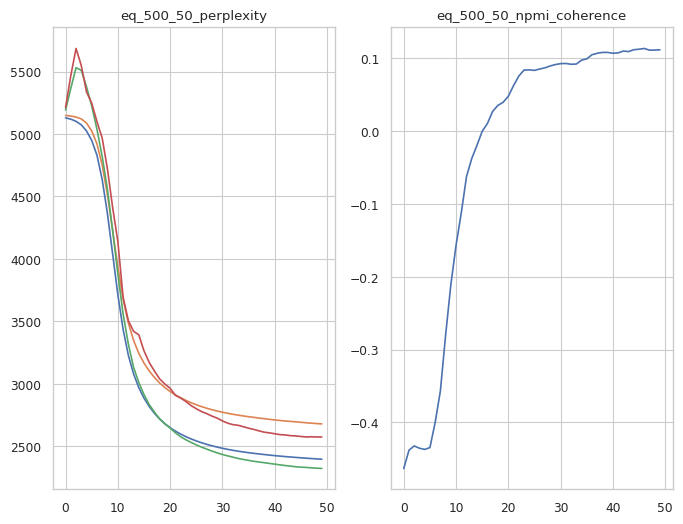

In [375]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))

ax1.plot(train_perplexity)
ax1.plot(test_perplexity)
ax1.plot(train_stratified_perplexity)
ax1.plot(test_stratified_perplexity)
ax1.set_title(structure_prefix + 'perplexity')

ax2.plot(npmi_coherence)
ax2.set_title(structure_prefix + 'npmi_coherence')

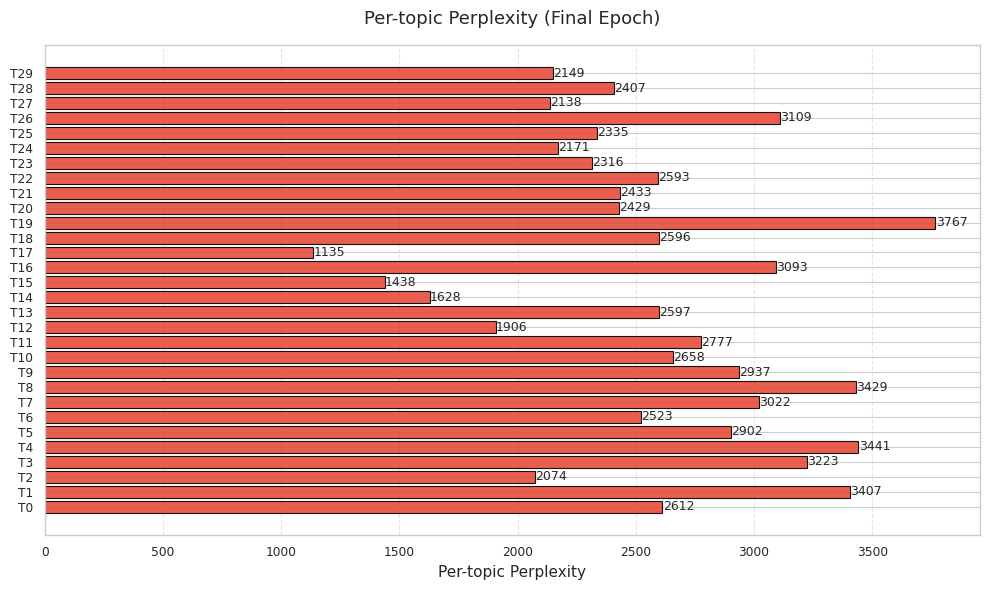

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Per-topic Perplexity (Final Epoch)'}, xlabel='Per-topic Perplexity'>)

In [379]:
plot_per_topic_ppl_boxplot(stratified_perplexity_ppl)

In [392]:
[(i, len(topic_anchors[i])) for i in range(30)]

[(0, 369),
 (1, 0),
 (2, 83),
 (3, 30),
 (4, 34),
 (5, 25),
 (6, 109),
 (7, 57),
 (8, 1),
 (9, 11),
 (10, 55),
 (11, 203),
 (12, 58),
 (13, 9),
 (14, 80),
 (15, 65),
 (16, 45),
 (17, 48),
 (18, 109),
 (19, 150),
 (20, 181),
 (21, 91),
 (22, 46),
 (23, 102),
 (24, 106),
 (25, 143),
 (26, 3),
 (27, 110),
 (28, 137),
 (29, 84)]

In [393]:
topic_num = 11
print(len(topic_anchors[topic_num]))
all_c = Counter()
for anchor in topic_anchors[topic_num]:
    c = Counter([data_targets[i] for i in lower_data if anchor in lower_data[i]])
    all_c.update(c)
print(all_c)

203
Counter({'soc.religion.christian': 8786, 'talk.religion.misc': 3305, 'alt.atheism': 2655, 'talk.politics.mideast': 1597, 'talk.politics.guns': 1115, 'sci.crypt': 1097, 'sci.med': 1064, 'talk.politics.misc': 960, 'sci.space': 940, 'rec.sport.hockey': 800, 'rec.autos': 720, 'rec.motorcycles': 698, 'comp.windows.x': 687, 'rec.sport.baseball': 663, 'comp.graphics': 613, 'sci.electronics': 598, 'comp.sys.ibm.pc.hardware': 542, 'comp.os.ms-windows.misc': 538, 'comp.sys.mac.hardware': 533, 'misc.forsale': 494})


In [ ]:
with open('500_50_5_src_' + 'metrics.json', 'r') as file:
    metrics = json.load(file)

train_perplexity = metrics['perplexity'][0::2]
test_perplexity = metrics['perplexity'][1::2]
npmi_coherence = metrics['npmi_coherence'][0::2]
train_stratified_perplexity = metrics['stratified_perplexity'][0::2]
test_stratified_perplexity = metrics['stratified_perplexity'][1::2]
print(f"{train_perplexity=}")
print(f"{test_perplexity=}")
print(f"{npmi_coherence=}")
print(f"{train_stratified_perplexity=}")
print(f"{test_stratified_perplexity=}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))

ax1.plot(train_perplexity)
ax1.plot(test_perplexity)
ax1.plot(train_stratified_perplexity)
ax1.plot(test_stratified_perplexity)
ax1.set_title('500_50_5_src_' + 'perplexity')

ax2.plot(npmi_coherence)
ax2.set_title('500_50_5_src_' + 'npmi_coherence')

In [ ]:
metrics

In [394]:
data[0]

"From: Mamatha Devineni Ratnam <mr47+@andrew.cmu.edu>\nSubject: Pens fans reactions\nOrganization: Post Office, Carnegie Mellon, Pittsburgh, PA\nLines: 12\nNNTP-Posting-Host: po4.andrew.cmu.edu\n\n\n\nI am sure some bashers of Pens fans are pretty confused about the lack\nof any kind of posts about the recent Pens massacre of the Devils. Actually,\nI am  bit puzzled too and a bit relieved. However, I am going to put an end\nto non-PIttsburghers' relief with a bit of praise for the Pens. Man, they\nare killing those Devils worse than I thought. Jagr just showed you why\nhe is much better than his regular season stats. He is also a lot\nfo fun to watch in the playoffs. Bowman should let JAgr have a lot of\nfun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final\nregular season game.          PENS RULE!!!\n\n"

In [395]:
def clean_20ng_document(content):
    
    # 1. Remove Headers (The first blank line separates header and body)
    parts = content.split('\n\n', 1)
    if len(parts) < 2:
        return "" # Skip if it's an empty or malformed file
    
    body = parts[1]
    
    # 2. Remove standard USENET footers
    # Regex to truncate lines that look like standard signatures or attributions
    body_lines = body.splitlines()
    cleaned_lines = []
    
    for line in body_lines:
        # Stop processing if we hit a signature block separator (like "--" or "---")
        if line.strip().startswith(('--', '---')):
            break
        cleaned_lines.append(line)
        
    return '\n'.join(cleaned_lines).strip()


In [397]:
print(clean_20ng_document(data[0]))

I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!


In [400]:
import pandas as pd
from sklearn.datasets import fetch_20newsgroups

# 1. Fetch the dataset (optional parameters shown to strip message metadata)
newsgroups = fetch_20newsgroups(
    subset='train', 
    remove=('headers', 'footers', 'quotes')
)

# 2. Create the DataFrame
df = pd.DataFrame({
    'text': newsgroups.data,
    'target': newsgroups.target
})

# 3. Map target numbers to their actual category names
df['target_name'] = df['target'].map(lambda x: newsgroups.target_names[x])

# View the first 3 rows
print(df.head(3))

                                                text  target  \
0  I was wondering if anyone out there could enli...       7   
1  A fair number of brave souls who upgraded thei...       4   
2  well folks, my mac plus finally gave up the gh...       4   

             target_name  
0              rec.autos  
1  comp.sys.mac.hardware  
2  comp.sys.mac.hardware  
